In [1]:
#!pip install torch

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import torch

import rank_compat as rc

In [3]:
n_total   = 25000         # total samples in the single dataset you will split
latent_dim = 8            # k
p          = 160          # observed features
mix_noise  = 0.80         # noise level for X
alpha_pair = 0.35         # strength of pairwise interaction term in f(V)
beta_sin   = 0.25         # strength of sinusoidal term in f(V)
scale_logit = 1.25        # scale for the logit so class overlap is moderate

rng = np.random.RandomState(42)

# 1) Latent factors
V = rng.normal(size=(n_total, latent_dim))

# 2) Nonlinear logit function of V
w = rng.normal(size=latent_dim)
pair_term = (V[:, :-1] * V[:, 1:]).sum(axis=1)  # sum of adjacent products
sin_term  = np.sin(V[:, 0])
score_true = (V @ w) + alpha_pair * pair_term + beta_sin * sin_term
score_true = score_true / scale_logit

# 3) Labels from Bernoulli(sigmoid(score_true))
proba_true = 1.0 / (1.0 + np.exp(-score_true))
y = rng.binomial(1, proba_true).astype(int)

# 4) Observed features: a noisy linear mix of V
M = rng.normal(size=(latent_dim, p))
# Normalize columns to avoid overly strong axes
M = M / np.linalg.norm(M, axis=0, keepdims=True)
X_clean = V @ M
X = X_clean + rng.normal(scale=mix_noise, size=X_clean.shape)

In [4]:
X_o, y_o = X[:500], y[:500]
X_u, y_u = X[:2500], y[:2500]
X_v, y_v = X[-3000:], y[-3000:]

In [5]:
f_o = rc.OriginalLRTrainer(d=p)
f_o.fit(X_o, y_o)

p_o_f_o = f_o.predict_proba(X_o)
p_u_f_o = f_o.predict_proba(X_u)
p_v_f_o = f_o.predict_proba(X_v)

print("AUROC(f_o) on D_o:", roc_auc_score(y_o, p_o_f_o))
print("AUROC(f_o) on D_u:", roc_auc_score(y_u, p_u_f_o))
print("AUROC(f_o) on D_v:", roc_auc_score(y_v, p_v_f_o))

AUROC(f_o) on D_o: 0.7071561278749441
AUROC(f_o) on D_u: 0.7179738813136163
AUROC(f_o) on D_v: 0.7004809743954481


In [6]:
f_u = rc.OriginalLRTrainer(d=p)
f_u.fit(X_u, y_u)

p_o_f_u = f_u.predict_proba(X_o)
p_u_f_u = f_u.predict_proba(X_u)
p_v_f_u = f_u.predict_proba(X_v)

print("AUROC(f_u) on D_o:", roc_auc_score(y_o, p_o_f_u))
print("AUROC(f_u) on D_u:", roc_auc_score(y_u, p_u_f_u))
print("AUROC(f_u) on D_v:", roc_auc_score(y_v, p_v_f_u))

AUROC(f_u) on D_o: 0.874031007751938
AUROC(f_u) on D_u: 0.8695678893796811
AUROC(f_u) on D_v: 0.8459659495021337


In [7]:
# 4. define torch model factory (updated model class, not the legacy one)
def make_model():
    return rc.LogisticHead(d=p)  # all 64 standardized features

device = "cpu"

# hyperparameter grids
weight_decay_list = [0.1, 0.01, 0.001]
alpha_list = np.arange(0,1.1, 0.1) # [0.0, 0.25, 0.5, 0.75, 1.0]  # include 1.0 to see baseline row appear if you like
s_list = [100.0]                  # you can shrink this to [100.0] to go faster
beta_list = np.arange(0,1.1, 0.1) # 

[0.0, 0.25, 0.5, 0.75, 1.0]

# training params
lr = 1e-3
batch_size = 256
epochs = 50

# 5 + 6 combined: build BCE pool and RBC grids
bce_runs, rbc_runs_by_s = rc.run_full_sweep(
    X_o, y_o, p_o_f_o,
    X_v, y_v, p_v_f_o,
    weight_decay_list=weight_decay_list,
    alpha_list=alpha_list,
    s_list=s_list,
    make_model_fn=make_model,
    lr=lr,
    batch_size=batch_size,
    epochs=epochs,
    device=device,
    n_bootstrap=45,   # you can raise to 45 later
    n_shuffle=5,
    seed=0,
)

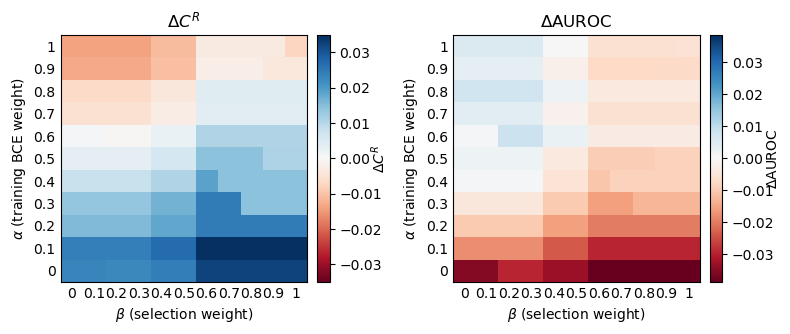

In [8]:
# 7. build heatmaps (deltas vs the best BCE model for each beta)
by_s = rc.build_heatmaps(
    bce_runs=bce_runs,
    rbc_runs_by_s=rbc_runs_by_s,
    alpha_list=alpha_list,
    beta_list=beta_list,
)

# 8. plot them
rc.plot_heatmaps_by_s(by_s)

In [9]:
# 1) Did we pick the same BCE run for all betas?
from collections import defaultdict
def pick_id(r):  # compact identity for a run
    return (r["family"], r.get("alpha"), r.get("s"), r["weight_decay"], r.get("rep_type"), r.get("rep_id"))

bce_choice_by_beta = {}
for b in beta_list:
    bce_choice_by_beta[b] = pick_id(rc._select_best_by_beta(bce_runs, b))
bce_choice_by_beta  # if all equal -> β-invariant anchor

# 2) For a fixed s and alpha, do AUROC and CR correlate ~1?
import numpy as np
s0 = list(rbc_runs_by_s.keys())[0]
alph0 = alpha_list[len(alpha_list)//2]
runs = [r for r in rbc_runs_by_s[s0] if r["alpha"]==alph0]
arr = np.array([[r["AUROC"], r["CR"]] for r in runs])
np.corrcoef(arr.T)  # if ~[[1, ρ],[ρ,1]] with ρ≈1, β won’t matter


array([[ 1.        , -0.91504906],
       [-0.91504906,  1.        ]])

In [10]:
# A) Compare absolute AUROC/CR distributions
def summarize(name, runs):
    import numpy as np
    AU = np.array([r["AUROC"] for r in runs]); CR = np.array([r["CR"] for r in runs])
    print(f"{name:10s} AUROC mean±sd {AU.mean():.3f}±{AU.std():.3f} | "
          f"CR mean±sd {CR.mean():.3f}±{CR.std():.3f} | n={len(runs)}")

summarize("BCE", [r for r in bce_runs if r["family"]=="BCE"])
for s_val, runs in rbc_runs_by_s.items():
    summarize(f"RBC s={s_val}", [r for r in runs if r["family"]=="RBC"])

# B) Check β actually changes the selected model (both anchors and RBC)
from collections import Counter
def run_id(r): return (r["family"], r.get("alpha"), r.get("s"), r.get("weight_decay"), r.get("rep_type"), r.get("rep_id"))
print("BCE anchors by β:")
print({b: run_id(rc._select_best_by_beta(bce_runs, b)) for b in beta_list})

s0 = list(rbc_runs_by_s)[0]
print("RBC choices by β for α=0.25, s=s0:")
pool = [r for r in rbc_runs_by_s[s0] if r["alpha"]==0.25]
print({b: run_id(max(pool, key=lambda r: b*r["AUROC"]+(1-b)*r["CR"])) for b in beta_list})

# C) Is CR improving on TRAIN for low-α?
#    (If not: implementation or optimization issue.)
def train_CR_snapshot(trainer, X, y, p_o):
    with torch.no_grad():
        p_u = trainer.predict_proba(X)
    return compute_CR_numpy(y, p_o, p_u)

# Train one α=0, large s, more epochs; expect train CR to go up


BCE        AUROC mean±sd 0.852±0.004 | CR mean±sd 0.899±0.009 | n=150
RBC s=100.0 AUROC mean±sd 0.847±0.012 | CR mean±sd 0.919±0.013 | n=33
BCE anchors by β:
{np.float64(0.0): ('BCE', 1.0, None, 0.1, 'bootstrap', 24), np.float64(0.1): ('BCE', 1.0, None, 0.1, 'bootstrap', 24), np.float64(0.2): ('BCE', 1.0, None, 0.1, 'bootstrap', 24), np.float64(0.30000000000000004): ('BCE', 1.0, None, 0.1, 'bootstrap', 24), np.float64(0.4): ('BCE', 1.0, None, 0.1, 'bootstrap', 41), np.float64(0.5): ('BCE', 1.0, None, 0.1, 'bootstrap', 41), np.float64(0.6000000000000001): ('BCE', 1.0, None, 0.01, 'bootstrap', 1), np.float64(0.7000000000000001): ('BCE', 1.0, None, 0.01, 'bootstrap', 1), np.float64(0.8): ('BCE', 1.0, None, 0.01, 'bootstrap', 1), np.float64(0.9): ('BCE', 1.0, None, 0.01, 'bootstrap', 1), np.float64(1.0): ('BCE', 1.0, None, 0.01, 'bootstrap', 1)}
RBC choices by β for α=0.25, s=s0:


ValueError: max() arg is an empty sequence